## 1. *Libraries Load Karna*
Sabse pehle hum Data Manipulation ke liye `dplyr` aur Visualization ke liye `ggplot2` load karenge.

In [1]:
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
#Loading Dataset
sleep_data <- read.csv("/content/Sleep_health_and_lifestyle_dataset.csv")

In [3]:
head(sleep_data)                               #head function gives 1st 6 values of dataset

,Person.ID,Gender,Age,Occupation,Sleep.Duration,Quality.of.Sleep,Physical.Activity.Level,Stress.Level,BMI.Category,Blood.Pressure,Heart.Rate,Daily.Steps,Sleep.Disorder
,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia


***## 2. Data Exploration aur Cleaning***

Yahan hum check karenge ki data mein koi "NA" (missing values) toh nahi hai. Hum `if-else` logic ka use karke data ki quality check karenge.

In [5]:
str(sleep_data)                #structure check krna

'data.frame':	374 obs. of  13 variables:
 $ Person.ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender                 : chr  "Male" "Male" "Male" "Male" ...
 $ Age                    : int  27 28 28 28 28 28 29 29 29 29 ...
 $ Occupation             : chr  "Software Engineer" "Doctor" "Doctor" "Sales Representative" ...
 $ Sleep.Duration         : num  6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 ...
 $ Quality.of.Sleep       : int  6 6 6 4 4 4 6 7 7 7 ...
 $ Physical.Activity.Level: int  42 60 60 30 30 30 40 75 75 75 ...
 $ Stress.Level           : int  6 8 8 8 8 8 7 6 6 6 ...
 $ BMI.Category           : chr  "Overweight" "Normal" "Normal" "Obese" ...
 $ Blood.Pressure         : chr  "126/83" "125/80" "125/80" "140/90" ...
 $ Heart.Rate             : int  77 75 75 85 85 85 82 70 70 70 ...
 $ Daily.Steps            : int  4200 10000 10000 3000 3000 3000 3500 8000 8000 8000 ...
 $ Sleep.Disorder         : chr  "None" "None" "None" "Sleep Apnea" ...


In [12]:
#missing values ( loop or dsa concept se)
na_count <- sum(is.na(sleep_data))
if(na_count > 0){
  print(paste("In DataSet", na_count,"has Missing values","Data need o be cleaned" ))
  sleep_data <- na.omit(sleep_data)
} else {
  print("Data is clean")
}


[1] "Data is clean"


In [13]:
#  Categorical consistency (unique values check karein)
unique(sleep_data$Gender)
unique(sleep_data$Occupation)

[1] "Male"   "Female"

[1] "Software Engineer"    "Doctor"               "Sales Representative"
 [4] "Teacher"              "Nurse"                "Engineer"            
 [7] "Accountant"           "Scientist"            "Lawyer"              
[10] "Salesperson"          "Manager"

## *3. Statistical Summary*
Hum `dplyr` ka use karke ek summary table banayenge jo Gender ke basis par average Sleep Duration dikhayegi.

In [21]:
summary_table <- sleep_data %>%
  group_by(Gender) %>%
  summarise(
    Avg_Sleep = mean(Sleep.Duration),
    Avg_Stress = median(Stress.Level),
    Count = n()
  )

print(summary_table)

# A tibble: 2 × 4
  Gender Avg_Sleep Avg_Stress Count
  <chr>      <dbl>      <int> <int>
1 Female      7.23          4   185
2 Male        7.04          6   189


## *4. Visualization (Graphs)*
Ab hum dekhhenge ki 'Physical Activity Level' aur 'Sleep Quality' ke beech kya rishta hai.

`geom_smooth()` using formula = 'y ~ x'


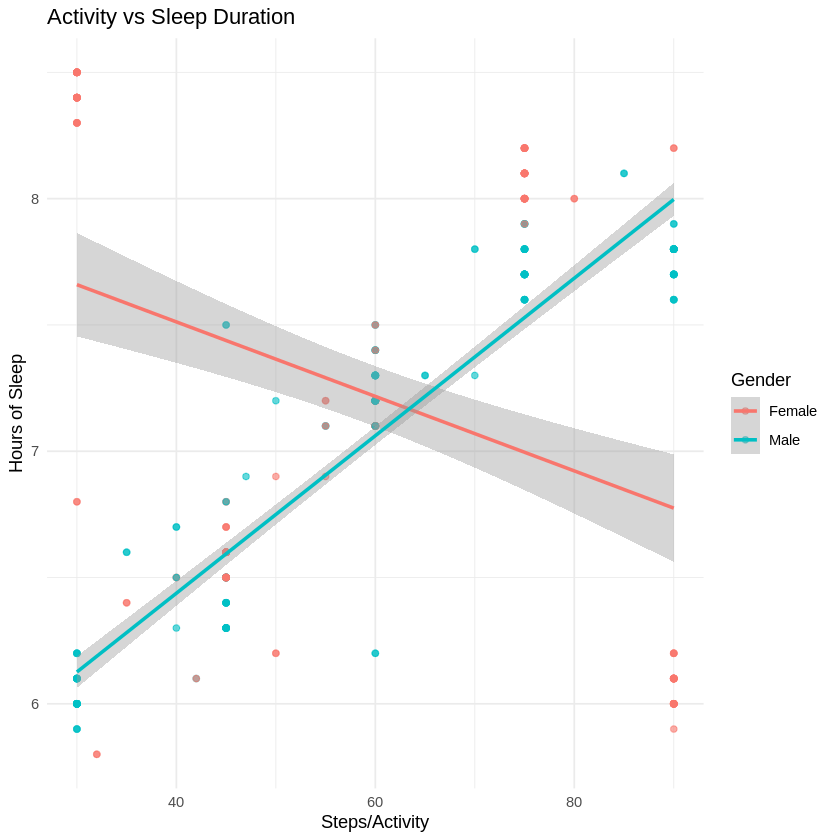

In [29]:
ggplot(sleep_data, aes(x=Physical.Activity.Level , y=Sleep.Duration , color= Gender))+
  geom_point(alpha=0.6)+
  geom_smooth(method='lm')+
  labs(title="Activity vs Sleep Duration" ,x="Steps/Activity", y="Hours of Sleep") +
  theme_minimal()



## *5. Hypothesis Testing*
Hum check karenge ki kya "Male" aur "Female" ki sleep duration mein koi significant difference hai ya ye sirf ek ittefaq hai. Iske liye hum **T-Test** ka use karenge.

In [30]:
# T-test perform karna
t_test_result <- t.test(Sleep.Duration ~ Gender, data = sleep_data)
print(t_test_result)


	Welch Two Sample t-test

data:  Sleep.Duration by Gender
t = 2.3565, df = 349.38, p-value = 0.019
alternative hypothesis: true difference in means between group Female and group Male is not equal to 0
95 percent confidence interval:
 0.03195795 0.35448564
sample estimates:
mean in group Female   mean in group Male 
            7.229730             7.036508 



In [31]:
# Result analyze karna
if(t_test_result$p.value < 0.05) {
  print("Difference significant hai!")
} else {
  print("Koi bada difference nahi mila.")
}

[1] "Difference significant hai!"
